# External Data Evaluation — MobileNetV2 Stringing Model

This notebook evaluates the **saved MobileNetV2 model** (`mobilenetv2_stringing_final.h5`) on a completely **external dataset** that was never seen during training or validation.

**What this notebook does:**
- Loads the saved model as-is (no retraining)
- Loads and preprocesses images from the additional data folders
- Runs inference (prediction only)
- Reports: Accuracy, Precision, Recall, F1-Score, and a Confusion Matrix

**External data location:**
```
Defect-Detection/additionnal data/
    ├── Stringing/camera1/     ← 5,000 images  (label = 1)
    └── No Stringing/camera1/  ← 5,000 images  (label = 0)
```

> **Note:** Preprocessing is identical to training — resize to 224×224, normalize pixels to [0, 1].

---
## 1. Imports

In [2]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

2026-05-15 11:43:03.689143: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778841783.798984    6366 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778841783.827988    6366 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-15 11:43:04.079409: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.18.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 2. Paths

All paths are defined here so they are easy to adjust if the folder layout changes.

In [3]:
# Notebook lives in:  Defect-Detection/Stringing/
# Model lives in the same folder.
# Additional data lives one level up, then into "additionnal data/".

BASE_DIR        = os.path.abspath(os.path.join(os.getcwd(), ".."))
MODEL_PATH      = os.path.join(os.getcwd(), "mobilenetv2_stringing_final.h5")

STRINGING_DIR   = os.path.join(BASE_DIR, "additionnal data", "Stringing",    "camera3")
NO_STRINGING_DIR= os.path.join(BASE_DIR, "additionnal data", "No Stringing", "camera3")

IMG_SIZE   = (224, 224)   # same as training
BATCH_SIZE = 32

# Quick sanity check
for p in [MODEL_PATH, STRINGING_DIR, NO_STRINGING_DIR]:
    exists = os.path.exists(p)
    print(f"{'✅' if exists else '❌'}  {p}")

✅  /home/feriel/PFE/Defect-Detection/Stringing/mobilenetv2_stringing_final.h5
✅  /home/feriel/PFE/Defect-Detection/additionnal data/Stringing/camera3
✅  /home/feriel/PFE/Defect-Detection/additionnal data/No Stringing/camera3


---
## 3. Load the Saved Model

We load the model that was produced at the end of the original training run.  
No compilation or retraining is needed — we only use it for `.predict()`.

In [3]:
model = keras.models.load_model(MODEL_PATH)
model.summary()

I0000 00:00:1778447739.946524  152925 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "MobileNetV2_Stringing"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_03 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,179 (9.87 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2 (12.00 B)

---
## 4. Build the External Test Dataset

We collect all `.jpg` image paths from both class folders and assign labels:
- **Stringing → 1**
- **No_Stringing → 0**

Then we build a `tf.data.Dataset` with the **exact same preprocessing** used during training:
1. Read JPEG file
2. Resize to 224 × 224
3. Cast to float32 and divide by 255 (normalize to [0, 1])

No augmentation is applied — this is test/inference time.

In [4]:
# ── Collect file paths + labels ──────────────────────────────────────────────
stringing_files    = sorted(glob.glob(os.path.join(STRINGING_DIR,    "*.jpg")))
no_stringing_files = sorted(glob.glob(os.path.join(NO_STRINGING_DIR, "*.jpg")))

print(f"Stringing images    : {len(stringing_files)}")
print(f"No_Stringing images : {len(no_stringing_files)}")
print(f"Total               : {len(stringing_files) + len(no_stringing_files)}")

all_files  = stringing_files + no_stringing_files
all_labels = [1] * len(stringing_files) + [0] * len(no_stringing_files)

# ── Preprocessing function (identical to training) ────────────────────────────
def load_and_preprocess(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0   # normalize to [0, 1]
    return img, label

# ── Build tf.data pipeline ────────────────────────────────────────────────────
AUTOTUNE = tf.data.AUTOTUNE

test_ds = (
    tf.data.Dataset.from_tensor_slices((all_files, all_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("\n✅ Test dataset ready.")

Stringing images    : 5000
No_Stringing images : 5000
Total               : 10000


I0000 00:00:1778841806.104712    6366 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5



✅ Test dataset ready.


---
## 5. Run Inference

We pass the entire test dataset through the model in a single `model.predict()` call.  
The output is a sigmoid probability for each image.  
We apply a **threshold of 0.5** to convert probabilities to binary predictions:
- probability ≥ 0.5 → predicted class = 1 (Stringing)
- probability < 0.5 → predicted class = 0 (No_Stringing)

In [5]:
y_pred_probs = model.predict(test_ds, verbose=1).ravel()
y_pred       = (y_pred_probs >= 0.5).astype(int)
y_true       = np.array(all_labels)

print(f"\nTotal predictions : {len(y_pred)}")
print(f"Predicted Stringing    (1): {y_pred.sum()}")
print(f"Predicted No_Stringing (0): {(y_pred == 0).sum()}")

I0000 00:00:1778447743.671675  153045 service.cc:148] XLA service 0x70b7cc003c60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778447743.671741  153045 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 2060 SUPER, Compute Capability 7.5
2026-05-10 22:15:43.719177: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778447744.125470  153045 cuda_dnn.cc:529] Loaded cuDNN version 90300


  5/313 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step

I0000 00:00:1778447747.524258  153045 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step

Total predictions : 10000
Predicted Stringing    (1): 2849
Predicted No_Stringing (0): 7151


---
## 6. Evaluation Metrics

We compute the standard binary classification metrics on the external test set.

In [6]:
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)

print("=" * 50)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 50)
print()
print(classification_report(
    y_true, y_pred,
    target_names=["No_Stringing", "Stringing"]
))

  Accuracy  : 0.3371  (33.71%)
  Precision : 0.2141
  Recall    : 0.1220
  F1-Score  : 0.1554

              precision    recall  f1-score   support

No_Stringing       0.39      0.55      0.45      5000
   Stringing       0.21      0.12      0.16      5000

    accuracy                           0.34     10000
   macro avg       0.30      0.34      0.30     10000
weighted avg       0.30      0.34      0.30     10000



---
## 7. Confusion Matrix

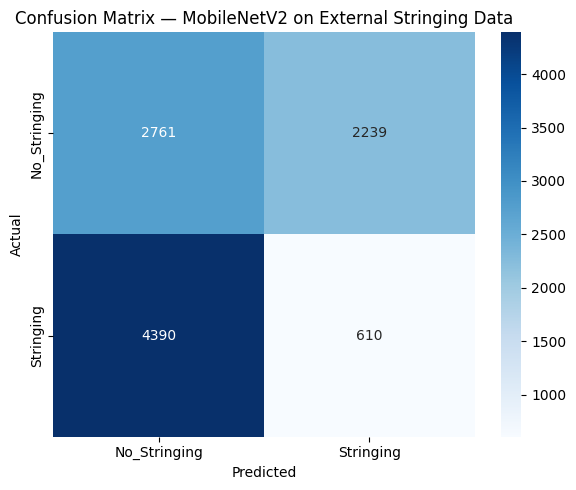

In [7]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No_Stringing", "Stringing"],
    yticklabels=["No_Stringing", "Stringing"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — MobileNetV2 on External Stringing Data")
plt.tight_layout()
plt.show()

---
## 8. Evaluate the Same External Data — 4-Class MobileNetV2 Model

We now run the same **Stringing** and **No Stringing** external images through the
**4-class unified model** (`mobilenetv2_4class_final.h5`).

The 4-class model predicts one of:

| Label index | Class |
|-------------|-------|
| 0 | Cracking |
| 1 | Stringing |
| 2 | Warping |
| 3 | No_Defect |

For these images the **expected** predictions are:
- `additionnal data/Stringing/` → label **1** (Stringing)
- `additionnal data/No Stringing/` → label **3** (No_Defect)

> Preprocessing is identical — resize to 224×224, normalize to [0, 1].

### Step 1 — Load the 4-Class Model

In [5]:
# 4-class model lives one level up from this notebook (Defect-Detection/)
MODEL_4CLASS_PATH = os.path.join(BASE_DIR, "mobilenetv2_4class_final.h5")

print(f"{'✅' if os.path.exists(MODEL_4CLASS_PATH) else '❌'}  {MODEL_4CLASS_PATH}")

model_4class = keras.models.load_model(MODEL_4CLASS_PATH)
model_4class.summary()

✅  /home/feriel/PFE/Defect-Detection/mobilenetv2_4class_final.h5


Model: "MobileNetV2_4Class"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_03 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,950 (9.87 MB)

 Trainable params: 1,535,044 (5.86 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

 Optimizer params: 2 (12.00 B)

### Step 2 — Reuse the Same Dataset

The `test_ds` pipeline (built in Step 4 above) already contains the correct images.
We reuse it — only the labels change for the 4-class interpretation:
- `Stringing` images → expected class index **1**
- `No Stringing` images → expected class index **3** (No_Defect)

In [6]:
# Expected 4-class labels for the same image order
# stringing_files (5000 images) → class 1
# no_stringing_files (5000 images) → class 3 (No_Defect)
CLASS_NAMES_4 = ["Cracking", "Stringing", "Warping", "No_Defect"]

y_true_4class = ([1] * len(stringing_files)) + ([3] * len(no_stringing_files))
y_true_4class = np.array(y_true_4class)

print(f"Expected Stringing (1) : {(y_true_4class == 1).sum()}")
print(f"Expected No_Defect (3) : {(y_true_4class == 3).sum()}")

Expected Stringing (1) : 5000
Expected No_Defect (3) : 5000


### Step 3 — Run Inference

In [7]:
# test_ds was built without labels in the pipeline; predictions are shape (N, 4)
y_pred_probs_4 = model_4class.predict(test_ds, verbose=1)   # (N, 4)
y_pred_4class  = np.argmax(y_pred_probs_4, axis=1)          # predicted class index

print(f"\nPrediction distribution:")
for i, name in enumerate(CLASS_NAMES_4):
    count = (y_pred_4class == i).sum()
    pct   = count / len(y_pred_4class) * 100
    print(f"  {name:<12} ({i}): {count:>5}  ({pct:.1f}%)")

I0000 00:00:1778841844.696862    6930 service.cc:148] XLA service 0x7510580032e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778841844.697480    6930 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 2060 SUPER, Compute Capability 7.5
2026-05-15 11:44:04.745386: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778841845.154887    6930 cuda_dnn.cc:529] Loaded cuDNN version 90300


  5/313 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step 

I0000 00:00:1778841848.849400    6930 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step

Prediction distribution:
  Cracking     (0):     0  (0.0%)
  Stringing    (1):  3082  (30.8%)
  Warping      (2):     0  (0.0%)
  No_Defect    (3):  6918  (69.2%)


### Step 4 — Evaluation Metrics (4-Class)

In [8]:
from sklearn.metrics import accuracy_score, classification_report

acc_4 = accuracy_score(y_true_4class, y_pred_4class)
print(f"Test Accuracy (4-class model): {acc_4:.4f}  ({acc_4*100:.2f}%)\n")
print(classification_report(
    y_true_4class,
    y_pred_4class,
    labels=[0, 1, 2, 3],
    target_names=CLASS_NAMES_4,
    zero_division=0,
))

Test Accuracy (4-class model): 0.3662  (36.62%)

              precision    recall  f1-score   support

    Cracking       0.00      0.00      0.00         0
   Stringing       0.28      0.17      0.22      5000
     Warping       0.00      0.00      0.00         0
   No_Defect       0.40      0.56      0.47      5000

    accuracy                           0.37     10000
   macro avg       0.17      0.18      0.17     10000
weighted avg       0.34      0.37      0.34     10000



### Step 5 — Confusion Matrix (4-Class)

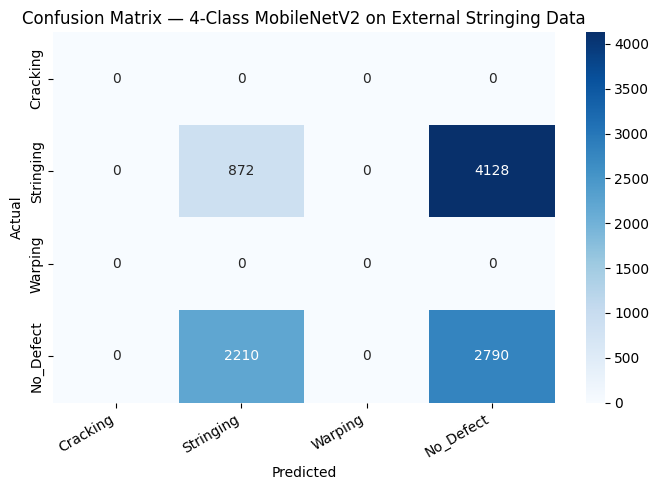

In [9]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_4 = confusion_matrix(y_true_4class, y_pred_4class, labels=[0, 1, 2, 3])

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_4,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES_4,
    yticklabels=CLASS_NAMES_4,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — 4-Class MobileNetV2 on External Stringing Data")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()